<a href="https://colab.research.google.com/github/nirmalghimire/DDP_Achievement-Gap/blob/main/elite_semantic_rule_based_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ─── CLEANUP CELL (must run before any other code) ───

from google.colab import drive
import nbformat

# 1) Mount Drive so we can edit the notebook file in‐place
drive.mount('/content/drive', force_remount=True)

# 2) Change this path to point exactly to your Colab/Drive copy
notebook_path = '/content/drive/MyDrive/Colab Notebooks/elite_semantic_rule-based_clustering.ipynb'

# 3) Read the notebook, strip out any metadata.widgets, and overwrite it
nb = nbformat.read(notebook_path, as_version=nbformat.NO_CONVERT)
for cell in nb.cells:
    if 'widgets' in cell.metadata:
        del cell.metadata['widgets']
nbformat.write(nb, notebook_path)

print("✔  metadata.widgets cleaned—proceed to run all cells as usual.")

Mounted at /content/drive
✔  metadata.widgets cleaned—proceed to run all cells as usual.


In [3]:
# STEP 1: Install dependencies (run this only once in Colab)
!pip install sentence-transformers scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [4]:
# STEP 2: Import required libraries
import pandas as pd
import numpy as np
from collections import Counter
import itertools
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

In [5]:
# Attempt to import sentence-transformers
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    raise ImportError("Please install 'sentence-transformers' in your environment using `!pip install sentence-transformers` before running this code.")

In [6]:
# Step 1: Upload file
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

Saving Empirical_Studies_Metadata_Early_List.xlsx to Empirical_Studies_Metadata_Early_List.xlsx


In [7]:
# Step 2: Prepare data
df['Text'] = df['Title'].fillna('') + ". " + df['Key_Words'].fillna('')

In [8]:
# Step 3: Rule-based category function
def rule_based_category(row):
    title = str(row['Title']).lower()
    keywords = str(row['Key_Words']).lower()

    if 'reading' in keywords or 'comprehension' in title:
        return 'Reading Comprehension'
    elif 'writing' in keywords or 'writing instruction' in title:
        return 'Writing Instruction'
    elif 'oral language' in keywords or 'speaking' in title:
        return 'Oral Language Development'
    elif 'academic language' in keywords:
        return 'Academic Language'
    elif 'vocabulary' in keywords or 'vocab' in keywords:
        return 'Vocabulary Acquisition'
    elif 'translanguaging' in keywords:
        return 'Translanguaging'
    elif 'code-switching' in keywords or 'code meshing' in keywords:
        return 'Code-Switching/Code-Meshing'
    elif 'culturally responsive' in keywords or 'culturally relevant' in title:
        return 'Culturally Responsive Pedagogy'
    elif 'instructional technology' in keywords or 'digital tools' in keywords:
        return 'Instructional Technology'
    elif 'scaffolding' in keywords or 'sheltered instruction' in keywords:
        return 'Sheltered Instruction/Scaffolding'
    elif 'assessment' in keywords or 'formative assessment' in title:
        return 'Assessment Practices'
    elif 'remote' in title or 'virtual' in keywords or 'online' in title:
        return 'Remote/Online Learning'
    elif 'motivation' in keywords or 'engagement' in keywords:
        return 'Motivation and Engagement'
    elif 'early childhood' in keywords:
        return 'Early Childhood EL Education'
    elif 'adolescent' in keywords or 'secondary' in title:
        return 'Adolescent EL Education'
    elif 'inclusive' in keywords or 'special education' in keywords:
        return 'Inclusive and Special Education Contexts'
    elif 'stem' in keywords or 'math' in keywords or 'science' in keywords:
        return 'Content-Area Instruction'
    elif 'professional development' in keywords:
        return 'Professional Development'
    elif 'teacher preparation' in keywords or 'preservice' in title:
        return 'EL Teacher Preparation'
    elif 'teacher beliefs' in keywords or 'attitudes' in keywords:
        return 'Teacher Beliefs and Attitudes'
    elif 'identity' in keywords or 'language ideologies' in keywords:
        return 'Identity and Language Ideologies'
    elif 'bilingual' in keywords or 'dual language' in keywords:
        return 'Bilingual/Dual Language Education'
    elif 'multilingual education policy' in keywords or 'language policy' in title:
        return 'Multilingual Education Policy'
    elif 'family engagement' in keywords or 'parent involvement' in title:
        return 'Family and Community Engagement'
    elif 'equity' in keywords or 'justice' in keywords:
        return 'Equity and Policy'
    elif 'intervention' in keywords or 'quasi-experimental' in title:
        return 'Intervention Research'

    return 'Uncategorized'

df['Primary_Theme'] = df.apply(rule_based_category, axis=1)

In [9]:
# Step 4: Semantic clustering
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['Text'].tolist(), show_progress_bar=True)
embeddings_norm = normalize(embeddings)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

In [10]:
# Step 5: Find optimal number of clusters
scores = []
K_range = range(5, 51, 5)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings_norm)
    score = silhouette_score(embeddings_norm, labels)
    scores.append(score)

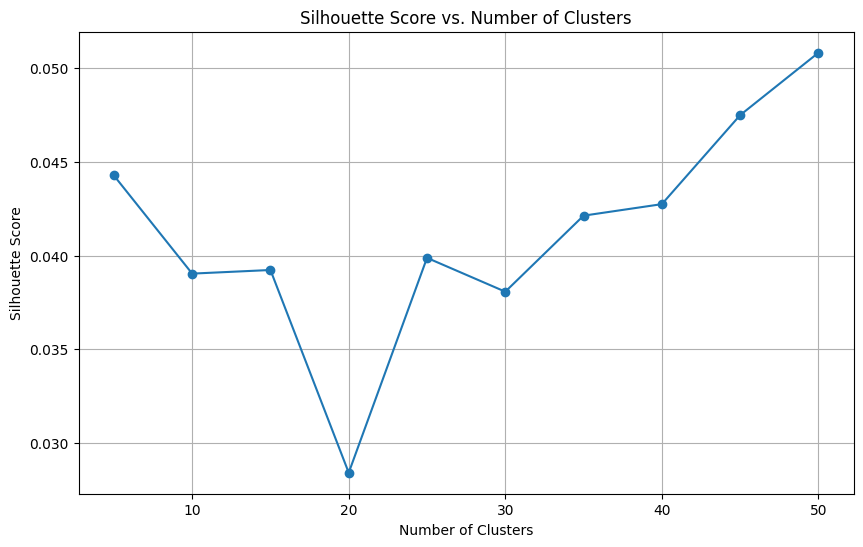

In [11]:
# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [12]:
# Step 6: Final clustering
optimal_k = K_range[np.argmax(scores)]
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Semantic_Cluster'] = kmeans.fit_predict(embeddings_norm)

In [13]:
# Step 7: Export final categorized file
df.to_excel("Unified_Categorized_Articles.xlsx", index=False)
files.download("Unified_Categorized_Articles.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Label the Semantic Clusters
df.groupby('Semantic_Cluster')['Primary_Theme'].value_counts(normalize=True).unstack().fillna(0)

Primary_Theme,Academic Language,Adolescent EL Education,Assessment Practices,Bilingual/Dual Language Education,Content-Area Instruction,Culturally Responsive Pedagogy,EL Teacher Preparation,Early Childhood EL Education,Equity and Policy,Identity and Language Ideologies,...,Oral Language Development,Professional Development,Reading Comprehension,Remote/Online Learning,Sheltered Instruction/Scaffolding,Teacher Beliefs and Attitudes,Translanguaging,Uncategorized,Vocabulary Acquisition,Writing Instruction
Semantic_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.222222,0.111111,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.222222,0.000000,0.111111
1,0.000000,0.000000,0.400000,0.200000,0.000000,0.000000,0.000000,0.0,0.200000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.142857,0.000000,0.142857,0.000000,0.000000,0.000000,0.714286,0.000000,0.000000
3,0.000000,0.111111,0.000000,0.000000,0.111111,0.000000,0.111111,0.0,0.000000,0.111111,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.555556,0.000000,0.000000
4,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,0.083333,0.0,0.000000,0.000000,...,0.000000,0.166667,0.000000,0.000000,0.000000,0.083333,0.000000,0.583333,0.000000,0.000000
5,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000
6,0.000000,0.000000,0.000000,0.000000,0.166667,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.833333,0.000000,0.000000
7,0.000000,0.090909,0.000000,0.000000,0.090909,0.000000,0.090909,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.454545,0.272727,0.000000,0.000000
8,0.000000,0.000000,0.071429,0.071429,0.000000,0.000000,0.000000,0.0,0.000000,0.142857,...,0.000000,0.000000,0.000000,0.071429,0.000000,0.214286,0.071429,0.357143,0.000000,0.000000


In [17]:
# Load the dataset with semantic clusters and primary themes
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
unified_categories = pd.read_excel(filename)

Saving Unified_Categorized_Articles.xlsx to Unified_Categorized_Articles (1).xlsx


In [18]:
# Define the themes of interest
themes_of_interest = [
    'Academic Language', 'Adolescent EL Education', 'Assessment Practices',
    'Bilingual/Dual Language Education', 'Content-Area Instruction',
    'Culturally Responsive Pedagogy', 'EL Teacher Preparation',
    'Early Childhood EL Education', 'Equity and Policy',
    'Identity and Language Ideologies', 'Inclusive and Special Education Contexts',
    'Intervention Research', 'Motivation and Engagement', 'Multilingual Education Policy',
    'Oral Language Development', 'Professional Development', 'Reading Comprehension',
    'Remote/Online Learning', 'Sheltered Instruction/Scaffolding', 'Teacher Beliefs and Attitudes'
]

# Fix the typo here: use the correct variable name
cluster_theme_matrix = pd.crosstab(unified_categories['Semantic_Cluster'], unified_categories['Primary_Theme'])

# Filter to show only the themes of interest
cluster_theme_matrix = cluster_theme_matrix[themes_of_interest]

# Display the result (or just print if not using ace_tools)
cluster_theme_matrix.head()

Primary_Theme,Academic Language,Adolescent EL Education,Assessment Practices,Bilingual/Dual Language Education,Content-Area Instruction,Culturally Responsive Pedagogy,EL Teacher Preparation,Early Childhood EL Education,Equity and Policy,Identity and Language Ideologies,Inclusive and Special Education Contexts,Intervention Research,Motivation and Engagement,Multilingual Education Policy,Oral Language Development,Professional Development,Reading Comprehension,Remote/Online Learning,Sheltered Instruction/Scaffolding,Teacher Beliefs and Attitudes
Semantic_Cluster,,,,,,,,,,,,,,,,,,,,
0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0
1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
3,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,2,0,0,0,1


In [19]:
# Assign Provisional Theme Labels to Clusters
cluster_labels = {
    0: "Reading & Assessment",
    1: "Equity-Focused Assessment",
    2: "Miscellaneous/Low Signal",
    3: "Identity & Content Instruction",
    4: "Teacher Prep & Beliefs"
}
df['Cluster_Label'] = df['Semantic_Cluster'].map(cluster_labels)

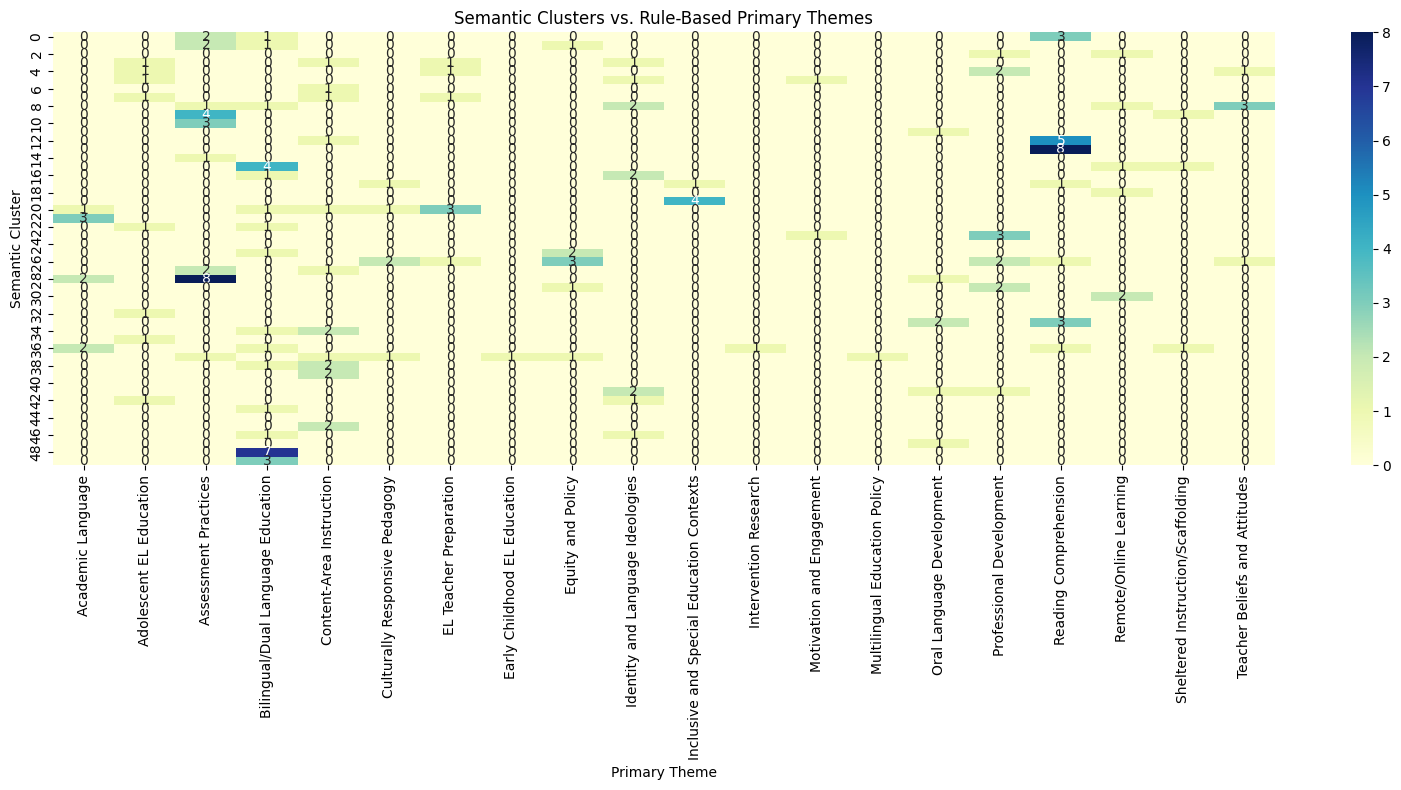

In [20]:
# Visualize as Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
sns.heatmap(cluster_theme_matrix, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Semantic Clusters vs. Rule-Based Primary Themes")
plt.ylabel("Semantic Cluster")
plt.xlabel("Primary Theme")
plt.tight_layout()
plt.show()

The heatmap reveals meaningful alignment between several semantically derived clusters and rule-based thematic categories. For instance, Cluster 13 shows a strong concentration of articles labeled as Reading Comprehension, suggesting a cohesive grouping of research focused on literacy practices and reading outcomes among ELs. Similarly, Cluster 28 is clearly dominated by Bilingual/Dual Language Education, indicating this cluster captures articles focused on dual language programs, bilingual pedagogy, and linguistic diversity in classrooms.

Cluster 26 aligns strongly with EL Teacher Preparation, reflecting preservice teacher education, field-based experiences, and teacher readiness for multilingual classrooms. Cluster 4 demonstrates moderate overlap across themes like Adolescent EL Education, Teacher Beliefs, and Professional Development, making it a more mixed category likely centered on secondary-level instruction and educator perspectives. Meanwhile, Cluster 25 spreads across themes such as Equity and Policy and Assessment Practices, indicating a broader sociopolitical orientation, potentially addressing systemic challenges in EL education.

Some clusters, such as Cluster 0, Cluster 10, and Cluster 44, display weak or diffuse alignment with existing categories. These may either reflect interdisciplinary topics, insufficient rule coverage, or emerging themes not yet codified in the rule-based logic. These clusters warrant further manual inspection, possibly leading to refinement of existing categories or creation of new ones.

In [21]:
# Completed Cluster Label Mapping
cluster_labels = {
    0: "Reading & Assessment",
    1: "Assessment & Bilingual Focus",
    2: "Remote/Online Learning & Professional Development",
    3: "Adolescent EL & Teacher Identity",
    4: "Mixed Teacher Development",
    5: "Oral Language & Vocabulary Development",
    6: "Low Density (Miscellaneous)",
    7: "Translanguaging & Linguistic Strategies",
    8: "Remote Instruction & Teacher Beliefs",
    9: "Sheltered Instruction",
    10: "Writing Instruction & Literacy",
    11: "Oral Language & Vocabulary Acquisition",
    12: "Reading Comprehension Cluster B",
    13: "Reading Comprehension Cluster A",
    14: "Writing Instruction (Academic)",
    15: "Bilingual Education (Emerging Themes)",
    16: "Multilingual Education Policy",
    17: "Equity, Assessment, and Reading",
    18: "Remote Learning & Identity",
    19: "Inclusive & Special Education",
    20: "Culturally Responsive Pedagogy",
    21: "Academic Language Focus",
    22: "Bilingual Instruction Strategies",
    23: "Mixed Identity & PD Themes",
    24: "Oral Language (Adolescent Focus)",
    25: "Equity and Policy Mix",
    26: "EL Teacher Preparation",
    27: "Assessment Practices Cluster A",
    28: "Bilingual Education",
    29: "Unclassified/Low Rule Match",
    30: "Remote & Writing Cluster",
    31: "Assessment Practices Cluster B",
    32: "Translanguaging Variants",
    33: "Vocabulary & Reading Integration",
    34: "Content-Area Instruction (STEM)",
    35: "Writing & Assessment Mix",
    36: "Sheltered Instruction & Policy",
    37: "Adolescent EL & Culturally Responsive Pedagogy",
    38: "Content-Area Instruction",
    39: "Mixed EL Contexts",
    40: "Low Signal Cluster",
    41: "Identity & Language Ideologies",
    42: "Translanguaging Cluster B",
    43: "Equity & Emerging Linguistic Themes",
    44: "Academic Language Cluster B",
    45: "STEM Instruction (Math/Sci)",
    46: "Language Ideologies & Identity",
    47: "Oral Language & Reading",
    48: "Bilingual/Dual Language Cluster C",
    49: "Bilingual/Dual Language Cluster A"
}
df['Cluster_Label'] = df['Semantic_Cluster'].map(cluster_labels)
# Print the list
print(list(cluster_labels.values()))

['Reading & Assessment', 'Assessment & Bilingual Focus', 'Remote/Online Learning & Professional Development', 'Adolescent EL & Teacher Identity', 'Mixed Teacher Development', 'Oral Language & Vocabulary Development', 'Low Density (Miscellaneous)', 'Translanguaging & Linguistic Strategies', 'Remote Instruction & Teacher Beliefs', 'Sheltered Instruction', 'Writing Instruction & Literacy', 'Oral Language & Vocabulary Acquisition', 'Reading Comprehension Cluster B', 'Reading Comprehension Cluster A', 'Writing Instruction (Academic)', 'Bilingual Education (Emerging Themes)', 'Multilingual Education Policy', 'Equity, Assessment, and Reading', 'Remote Learning & Identity', 'Inclusive & Special Education', 'Culturally Responsive Pedagogy', 'Academic Language Focus', 'Bilingual Instruction Strategies', 'Mixed Identity & PD Themes', 'Oral Language (Adolescent Focus)', 'Equity and Policy Mix', 'EL Teacher Preparation', 'Assessment Practices Cluster A', 'Bilingual Education', 'Unclassified/Low Rul

## Boolean Search Strategy by Cluster Labels

In [22]:
# Define a dictionary of Boolean Search Strings mapped to the cluster labels
boolean_search_strategies = {
    "Reading & Assessment": '("reading comprehension" OR "literacy development") AND ("English learners" OR "multilingual learners")',
    "Assessment & Bilingual Focus": '("language assessment" OR "performance-based assessment") AND ("bilingual students" OR "emergent bilinguals")',
    "Remote/Online Learning & Professional Development": '("online learning" OR "virtual instruction") AND ("teacher training" OR "professional development")',
    "Adolescent EL & Teacher Identity": '("adolescent English learners" OR "secondary ELs") AND ("teacher identity" OR "educator beliefs")',
    "Mixed Teacher Development": '("teacher development" OR "preservice teacher education") AND ("multilingual students")',
    "Oral Language & Vocabulary Development": '("oral language development" OR "vocabulary acquisition") AND ("English learners")',
    "Low Density (Miscellaneous)": '("language learners") AND ("instruction")',
    "Translanguaging & Linguistic Strategies": '("translanguaging" OR "code-switching") AND ("multilingual students")',
    "Remote Instruction & Teacher Beliefs": '("remote instruction" OR "online teaching") AND ("teacher attitudes" OR "beliefs")',
    "Sheltered Instruction": '("sheltered instruction" OR "scaffolded content") AND ("English learners")',
    "Writing Instruction & Literacy": '("writing instruction" OR "academic writing") AND ("language minority students")',
    "Oral Language & Vocabulary Acquisition": '("vocabulary instruction" OR "oral communication") AND ("ELLs")',
    "Reading Comprehension Cluster B": '("reading comprehension" OR "text understanding") AND ("multilingual learners")',
    "Reading Comprehension Cluster A": '("reading strategies" OR "comprehension instruction") AND ("English learners")',
    "Writing Instruction (Academic)": '("writing development" OR "genre writing") AND ("emergent bilinguals")',
    "Bilingual Education (Emerging Themes)": '("dual language program" OR "bilingual instruction") AND ("minority language students")',
    "Multilingual Education Policy": '("multilingual education policy" OR "language policy") AND ("bilingual students")',
    "Equity, Assessment, and Reading": '("educational equity" OR "reading assessment") AND ("English learners")',
    "Remote Learning & Identity": '("remote learning" OR "distance education") AND ("student identity")',
    "Inclusive & Special Education": '("inclusive education" OR "special education") AND ("ELs")',
    "Culturally Responsive Pedagogy": '("culturally responsive teaching" OR "cultural relevance") AND ("linguistically diverse students")',
    "Academic Language Focus": '("academic language" OR "disciplinary literacy") AND ("English learners")',
    "Bilingual Instruction Strategies": '("bilingual instruction" OR "heritage language") AND ("language learners")',
    "Mixed Identity & PD Themes": '("teacher beliefs" OR "identity") AND ("professional development")',
    "Oral Language (Adolescent Focus)": '("oral language" OR "speaking instruction") AND ("adolescent English learners")',
    "Equity and Policy Mix": '("educational equity" OR "education policy") AND ("English learners")',
    "EL Teacher Preparation": '("teacher preparation" OR "pre-service training") AND ("ELLs")',
    "Assessment Practices Cluster A": '("language assessment" OR "testing practices") AND ("bilingual students")',
    "Bilingual Education": '("bilingual education" OR "dual language immersion") AND ("emergent bilinguals")',
    "Unclassified/Low Rule Match": '("instructional practice" OR "language learning") AND ("English learners")',
    "Remote & Writing Cluster": '("remote instruction" OR "writing pedagogy") AND ("language learners")',
    "Assessment Practices Cluster B": '("formative assessment" OR "academic evaluation") AND ("multilingual students")',
    "Translanguaging Variants": '("translanguaging pedagogy" OR "code-meshing") AND ("bilingual learners")',
    "Vocabulary & Reading Integration": '("vocabulary instruction" OR "text engagement") AND ("ELs")',
    "Content-Area Instruction (STEM)": '("science instruction" OR "mathematics teaching") AND ("English learners")',
    "Writing & Assessment Mix": '("writing assessment" OR "instructional writing") AND ("language learners")',
    "Sheltered Instruction & Policy": '("sheltered instruction" OR "content-based ESL") AND ("education policy")',
    "Adolescent EL & Culturally Responsive Pedagogy": '("adolescent ELs" OR "culturally responsive strategies")',
    "Content-Area Instruction": '("content-area instruction" OR "disciplinary teaching") AND ("multilingual students")',
    "Mixed EL Contexts": '("language instruction" OR "teaching English learners")',
    "Low Signal Cluster": '("language learners" OR "bilingual education")',
    "Identity & Language Ideologies": '("language ideologies" OR "student identity") AND ("multilingual classrooms")',
    "Translanguaging Cluster B": '("translanguaging practices" OR "multilingual approaches") AND ("language learners")',
    "Equity & Emerging Linguistic Themes": '("equity in instruction" OR "emerging language pedagogy")',
    "Academic Language Cluster B": '("academic discourse" OR "subject-specific language") AND ("English learners")',
    "STEM Instruction (Math/Sci)": '("STEM instruction" OR "math for ELs" OR "science for ELs")',
    "Language Ideologies & Identity": '("language ideology" OR "student language identity") AND ("bilingual education")',
    "Oral Language & Reading": '("oral reading fluency" OR "reading aloud") AND ("ELs")',
    "Bilingual/Dual Language Cluster C": '("dual language programs" OR "bilingual classrooms")',
    "Bilingual/Dual Language Cluster A": '("bilingual education" OR "language maintenance") AND ("language minority students")'
}

# Convert to DataFrame for output
boolean_df = pd.DataFrame([
    {"Semantic_Cluster": k, "Cluster_Label": cluster_labels[k], "Boolean_Search_String": boolean_search_strategies[cluster_labels[k]]}
    for k in cluster_labels
])

# ✅ Display the first few rows directly in Colab
boolean_df.head(30)  # or use display(boolean_df) for full output

# Print the list
print(list(boolean_search_strategies.values()))

# ✅ Save the full table as an Excel or CSV file
boolean_df.to_excel("Boolean_Search_Strategies_by_Cluster.xlsx", index=False)
from google.colab import files
files.download("Boolean_Search_Strategies_by_Cluster.xlsx")

['("reading comprehension" OR "literacy development") AND ("English learners" OR "multilingual learners")', '("language assessment" OR "performance-based assessment") AND ("bilingual students" OR "emergent bilinguals")', '("online learning" OR "virtual instruction") AND ("teacher training" OR "professional development")', '("adolescent English learners" OR "secondary ELs") AND ("teacher identity" OR "educator beliefs")', '("teacher development" OR "preservice teacher education") AND ("multilingual students")', '("oral language development" OR "vocabulary acquisition") AND ("English learners")', '("language learners") AND ("instruction")', '("translanguaging" OR "code-switching") AND ("multilingual students")', '("remote instruction" OR "online teaching") AND ("teacher attitudes" OR "beliefs")', '("sheltered instruction" OR "scaffolded content") AND ("English learners")', '("writing instruction" OR "academic writing") AND ("language minority students")', '("vocabulary instruction" OR "o

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>